# V768 - Measuring Vision with Psychophysics

## Lab 3 - Forced Choice Experiments

In [1]:
from pathlib import Path
from statistics import NormalDist
import re

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

try:
    import psignifit as ps
    import psignifit.psigniplot as psp
except ImportError:
    ps = None
    psp = None

try:
    from scipy.optimize import least_squares
except ImportError:
    least_squares = None

In Lab 1, you measured signal detection performance using the method of constant stimuli. Each trial required you to answer the question "Did you see a stimulus?". This was a yes-no task, also sometimes called a **simple forced choice** experiment.

In this lab, you will measure signal detection performance using a **two-alternative forced choice (2AFC)** experiment. Each trial will require you to answer the question "Did you see a stimulus on the left or the right of the screen?", even if you did not see a stimulus on either side.

This lab will show you how to fit a **psychometric function** to the resulting data. How similar or different will those curves be? What about them will be similar or different? Let's find out!

### Learning Outcomes

(i.e., what you will be able to do at the end of this lab)

- Describe simple forced choice and two-alternative forced choice experiments. Identify similarites and differences.

- Describe a psychometric curve.

- For a psychometric function with parameters mu, sigma, guess rate, and lapse rate, explain the signficance of each parameter.

- Explain why some psychometric curves have a floor of 0% and others have a floor of 50%.

### Questions

- Include and write a caption for the figure in Part C, Step 1.

- Include and write a caption for the table in Part C, Step 2.

- List the parameters of the psychometric function used for this lab. Describe the signficance of each, including the impact that changing its value will have on the resulting curve.

- Describe simple forced choice and two-alternative forced choice experiments, and discuss their similarities and differences.

- Reflect on what you know about these two experiment types and what you have observed. Do you think both are measuring the same thing? Do you expect that their results are usually similar or different? Do you think that one is likely more reliable than the other? Explain your reasoning.

## A. Method of Constant Stimuli

### Step 1. Data collection

In the first lab, you collected data using the PsychoPy experiment file "method-of-constant-stimuli.psyexp", so you've already completed data collection for this part of the lab!

### Step 2. Load your data

*(Reminder: PsychoPy will save your experiment data to a "data" folder inside of the same folder as the ".psyexp" file. The filename will start with the subject ID you used and end with the date/time of data collection.)*

Find the name of the ".csv" file containing your experiment data, and enter it below. Then run this section of code.

In [2]:
data_dir = Path.cwd().parent / "01-classical-methods" / "method-of-constant-stimuli" / "data"

# THIS IS THE SUBJECT NAME OR NUMBER YOU ASSIGNED FOR THE PREVIOUS LAB; IT IS DIFFERENT FROM THE FORCED CHOICE EXPERIMENT FROM LAB 3
subject_saved = "demo" # Change this to the subject number or name you want to analyze

subject_pattern = re.compile(rf"^{subject_saved}_")

matches = [f for f in data_dir.iterdir() if f.is_file() and f.suffix == '.csv' and subject_pattern.match(f.name)]

df = pd.read_csv(matches[0])
df.head()

,contrast,thisN,thisTrialN,thisRepN,response.keys,response.rt,response.duration,trials.thisRepN,trials.thisTrialN,trials.thisN,...,trials.response.rt,trials.response.duration,participant,session,date,expName,psychopyVersion,frameRate,expStart,Unnamed: 31
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,demo,1,2025-01-16_21h16.39.043,method_of_constant_stimuli,2024.2.4,NaN,2025-01-16 21h16.45.421908 -0500,NaN
1,0.9000,0.0,0.0,0.0,up,0.426800,NaN,0.0,0.0,0.0,...,0.426800,NaN,demo,1,2025-01-16_21h16.39.043,method_of_constant_stimuli,2024.2.4,NaN,2025-01-16 21h16.45.421908 -0500,NaN
2,0.0000,1.0,1.0,0.0,down,1.335804,NaN,0.0,1.0,1.0,...,1.335804,NaN,demo,1,2025-01-16_21h16.39.043,method_of_constant_stimuli,2024.2.4,NaN,2025-01-16 21h16.45.421908 -0500,NaN
3,0.0001,2.0,2.0,0.0,down,0.395193,NaN,0.0,2.0,2.0,...,0.395193,NaN,demo,1,2025-01-16_21h16.39.043,method_of_constant_stimuli,2024.2.4,NaN,2025-01-16 21h16.45.421908 -0500,NaN
4,0.0010,3.0,3.0,0.0,down,0.655127,NaN,0.0,3.0,3.0,...,0.655127,NaN,demo,1,2025-01-16_21h16.39.043,method_of_constant_stimuli,2024.2.4,NaN,2025-01-16 21h16.45.421908 -0500,NaN


In [3]:
# The first row of the CSV file contains the column names, so we can drop it and reset the index
df  = df.iloc[1:].reset_index(drop=True)

# Dropping things that are not needed for our analysis
df = df.drop(columns=["notes", "begin_experiment.started", "begin_experiment.stopped"])

In [4]:
df.columns

Index(['contrast', 'thisN', 'thisTrialN', 'thisRepN', 'response.keys',
       'response.rt', 'response.duration', 'trials.thisRepN',
       'trials.thisTrialN', 'trials.thisN', 'trials.thisIndex', 'thisRow.t',
       'trial.started', 'grating.started', 'grating.stopped',
       'response.started', 'polygon.started', 'trial.stopped',
       'trials.response.keys', 'trials.response.rt',
       'trials.response.duration', 'participant', 'session', 'date', 'expName',
       'psychopyVersion', 'frameRate', 'expStart', 'Unnamed: 31'],
      dtype='object')

### Step 3. Analyze your data

For this experiment, PsychoPy saved the stimulus contrast and the participant's response per trial. The responses were stored as 'up' (stimulus present) or 'down' (stimulus not present).

In [5]:
# convert the response key to true for up and false for down
df["response"] = df["response.keys"].eq('up')

#### Find percentage of stimuli reported present (up), as a function of contrast

For each contrast level, how often did you report that a stimulus was present?

In [6]:
# average across responses per contrast level
analysis_table = df[["response", "contrast"]].copy()
detection_results = (
    analysis_table
    .groupby('contrast', as_index=False)
    .agg(mean_response=('response', 'mean'))
)

# display percentages
percent_detected = pd.DataFrame({
    "contrast": detection_results["contrast"],
    "reported present (%)": detection_results["mean_response"] * 100
})

percent_detected =percent_detected.style.format(lambda x: f"{x:.6f}".rstrip('0').rstrip('.'))
display(percent_detected)

,contrast,reported present (%)
0,0,30
1,0.00001,26.666667
2,0.0001,23.333333
3,0.001,40
4,0.01,96.666667
5,0.1,100
6,0.9,100


**Take a look at these percentages.** What is the maximum? What is the minimum?

**Think about the design of this experiment** (i.e., what the stimuli looked like, what the task was, what the potential responses were, etc.). What results would you get if you were performing at chance level? In other words, what would happen if you just guessed on every trial?

**Looking again at your results,** when did you perform at chance level? Above chance? Below chance? What does that say about what contrast levels you can and cannot see? Is the boundary between the levels you can and cannot see very clear, or is there a gradual transition between contrasts you definitely can and definitely cannot see?

#### Plot responses as a function of contrast

Let's plot those percentages and take a look at the curve they form.

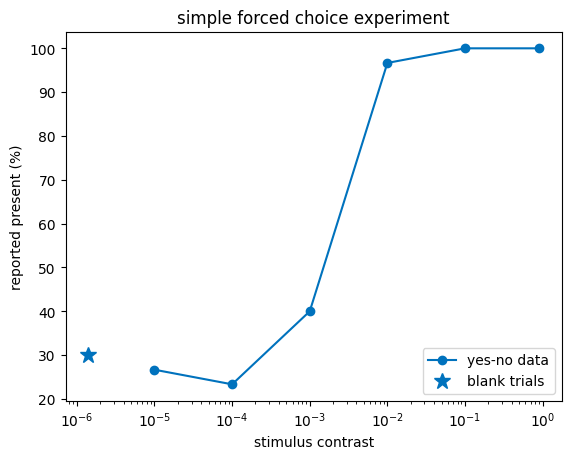

In [ ]:
fig, ax = plt.subplots()

# stash RGB values for default Python colors
# (blue, orange, gold, purple, green, sky blue, red)
rgb = np.array([
    [0, 0.447, 0.741], [0.85, 0.325, 0.098], [0.929, 0.694, 0.125],
    [0.494, 0.184, 0.556], [0.466, 0.674, 0.188], [0.301, 0.745, 0.933], [0.635, 0.078, 0.184]
])

positive_detection_results = detection_results[detection_results["contrast"] > 0]
blank_detection_results = detection_results[detection_results["contrast"] == 0]

# plot with stimulus contrast on a log scale
# (trials with zero contrast will not be included)
ax.plot(
    positive_detection_results["contrast"], positive_detection_results["mean_response"] * 100,
    'o-', color=rgb[0], markerfacecolor=rgb[0]
)
ax.set_xscale('log')
ax.set_title("simple forced choice experiment")
ax.set_xlabel('stimulus contrast')
ax.set_ylabel('reported present (%)')

# add a dot for zero contrast (blank) trials
x_val_for_detection_blanks = (  # pick dummy value for plotting zero contrast results
    positive_detection_results["contrast"].iloc[0] / 10 +  # move a 10^-1 step below the smallest value
    positive_detection_results["contrast"].iloc[0] / 25  # shift slightly to the right (off the y-axis line)
)

if not blank_detection_results.empty:
    ax.plot(
        x_val_for_detection_blanks, blank_detection_results["mean_response"].iloc[0] * 100,
        marker='*', markersize=12, linestyle='None', color=rgb[0], markerfacecolor=rgb[0]
    )
ax.legend(["yes-no data", "blank trials"], loc='lower right')
plt.show()

In [8]:
blank_detection_results

,contrast,mean_response
0,0.0,0.3


**Looking at this curve,** does the shape remind you of anything? Perhaps a sigmoid? A cumulative density function (CDF)? A psychometric function?

### Step 4. Fit a psychometric function to your data

**Psychometrics** is a field of study that aims to objectively measure variables that cannot be directly observed (e.g., a person's absolute contrast threshold). A **psychometric function** models the relationship between a given stimulus feature (e.g., contrast) and a participant's forced-choice responses. After we fit a psychometric function to data from a detection or discrimination task, we can infer certain things about that stimulus-response relationship (i.e., a psychometric function is an ***inferential model***).

As the stimulus property of interest increases (left to right on the x-axis), psychometric functions tend to ***gradually*** increase from their **floor** to their **ceiling** (low to high on the y-axis), forming S-shaped curves.



<img src="./week_3_forced_choice_assets/media/image1.png" alt="psychometric_curve.png" width="500" style="display:block; margin-left:auto; margin-right:auto;">


There are several reasons why this increase tends to be gradual. A practical reason for the typical S-shape is that psychophysicists usually want to measure the limits of perception, so their experiments tend to include multiple stimulus levels that are difficult but not impossible to perceive. A related reason is that gradual increases in stimulus levels tend to gradually, not suddenly, impact perception. (Imagine gradually turning the lights on or off using a dimmer switch. The resulting changes in your perception are also gradual.)

A third reason is that your nervous system's response to the exact same stimulus will <u>*not*</u> always be the exact same. This is both because there are factors that can modulate the strength of your system's response (e.g., your level of attention) and because neural responses are ***inherently variable*** (i.e., "noisy"). A common way to express these ideas is the maxim "<u>**perception is probabilistic**</u>, not deterministic". (The future state of a <u>deterministic</u> system <u>*does not*</u> depend on random chance, so you can <u>*determine*</u> what that future state will be. In contrast, the future state of a <u>probabilistic</u> system <u>*does*</u> depend on random chance, so you can only <u>*predict*</u> what that future state will be.)


#### What is the equation of a psychometric function?

There isn't one "true" equation for psychometric functions. You might come across a variety of different equations in textbooks and journal articles.

For this lab, we'll use an equation that builds on the normal cumulative density function (CDF). A Gaussian CDF has two parameters: the **mean** (mu, $\mu$) and the **standard deviation** (sigma, $\sigma$).



<img src="./week_3_forced_choice_assets/media/image2.png" alt="standard_normcdf.png" width="500" style="display:block; margin-left:auto; margin-right:auto;">


The y-axis values of a CDF can range from 0 to 1 (0% to 100%). You may notice, however, that psychometric curves don't always reach 0 or 1. For example, let's say that performance on a certain task only falls between 30% and 90%. What can we add to our equation to account for that?

A **guess rate** (gamma, $\gamma$) will to adjust the function's minimum value, and a **lapse rate** (lambda, $\lambda$) will adjust the function's maximum value. Both values convey the ***magnitude*** of the adjustment. For example, a guess rate of 30% would shift the function's minimum value from 0% to 30%, and a lapse rate of 10% would shift the function's maximum value from 100% to 90%.

<img src="./week_3_forced_choice_assets/media/image3.png" alt="psychometric_rates.png" width="500" style="display:block; margin-left:auto; margin-right:auto;">

**How do we incorporate the guess and lapse rates into our equation?** Let's say we want to change the bounds of our curve from 0 and 1 to 0.3 to 0.9 (30% to 90%). As we just covered, that means implementing a guess rate of 0.3 and a lapse rate of 0.1. Both of these rates reduce our function's height (meaning, how much of the y-axis that it can traverse). Thus, subtracting those rates from the maximum value of a CDF (1; 100%) gives us the height that we want our curve to have: $1-0\ldotp 3-0\ldotp 1=0\ldotp 6$. We can adjust our curve's height by scaling our CDF by the height we want (i.e., by multiplying the CDF by 0.6; 100% will become 60%, 50% will become 30%, etc.). After scaling, our curve will range from 0 to 0.6, which is 0.3 from where we want it to be. Thus, the second (and last) thing that we need to do is shift our curve up by our desired minimum value, which is equal to our guess rate, 0.3. (*Note: This isn't essential to understand, but at least give it a try to help grow your ability to make sense of equations.*)

The **equation** that we end up with for our **psychometric function** $\psi$ is

$$
\mathbf{p}=\psi \left(\mathbf{x};\mu ,\sigma ,\gamma ,\lambda \right)=\textrm{CDF}\left(\mathbf{x};\mu ,\sigma \right)\cdot \left(1-\gamma -\lambda \right)+\gamma
$$


where $\mathbf{x}$ represents the levels of the stimulus feature of interest (contrast) and $\mathbf{p}$ represents the corresponding response probabilities. The vector (i.e., set of values) $\mathbf{x}$ is the input to the functions $\psi$ and $\textrm{CDF}$, and the variables after the semicolon are that function's parameters.


#### Set up for curve fitting

To fit the function we just defined to data, we need to pick a guess for each of our parameter values ($\mu ,\sigma ,\gamma ,\lambda$). This will be the first combination of values that Python tests. To perform fitting, Python will (1) find the curve produced by our function $\psi$, our stimulus levels $\mathbf{x}$, and the set of parameter values; (2) compare that curve to the data; and (3) keep changing the parameter values until it finds a curve that's ***optimally*** close to the data (i.e., as close as Python thinks it can find). This process is called **optimization**.

Keep in mind that, even with identical input values, optimization won't always produce the same result and that sometimes it requires quite a bit of fine-tuning.

One way to fine-tune an optimization procedure is to place bounds on your parameters, restricting the values they can have. In this case, our sigma, guess rate, and lapse rate values should not be negative, so we'll implement lower bounds of 0 for those parameters. (And we'll also ask Python not to display any output to give us less to scroll through.)

In [9]:
# define psychometric function to fit
def normcdf(x, mu, sigma):
    x = np.asarray(x, dtype=float)
    sigma = max(float(sigma), np.finfo(float).eps)
    dist = NormalDist(float(mu), sigma)
    return np.vectorize(dist.cdf, otypes=[float])(x)

def psyfxn(c, x):
    c = np.asarray(c, dtype=float)
    return (normcdf(x, c[0], c[1]) * (1 - c[2] - c[3])) + c[2]
# c(1) = mu
# c(2) = sigma
# c(3) = guess rate
# c(4) = lapse rate

# choose starting values
c0 = np.array([0, 1, 0, 0], dtype=float)

# choose lower bounds
c_low_b = np.array([-np.inf, 0, 0, 0], dtype=float)

# suppress lsqcurvefit auto-printing
# (e.g., "Local minimum found. Optimization completed because the size of
# the gradient is less than the value of the optimality tolerance.
# <stopping criteria details>")
# opts = optimset('Display','off');

#### Fit your data

Now that we've chosen our function, initial guesses, and optional settings, we're ready to try fitting data from our yes-no task!

Note that we've been plotting our contrast levels on a ***logarithmic scale***. (Since $\log_{10} {\textrm{10}}^x =x$, you can think of plotting on a log scale as treating ${\textrm{10}}^{-3}$, ${\textrm{10}}^{-2}$, and ${\textrm{10}}^{-1}$ like they were $-3$, $-2$, and $-1$.) Because contrast is better represented by a log scale (vs. a linear scale), we're going to fit the $\log_{10}$ of our contrast values. Thus, our mu and sigma values will be on a log scale as well (i.e., if Python outputs a mu of $-3$, that means mu is ${\textrm{10}}^{-3}$).

In [10]:
# fit function to data
if least_squares is None:
    raise ImportError("scipy is required for least-squares curve fitting in this converted notebook.")

with np.errstate(divide='ignore'):
    x_detection = np.log10(detection_results["contrast"].to_numpy(dtype=float))  # x values of psychometric curve
y_detection = detection_results["mean_response"].to_numpy(dtype=float)  # y values of psychometric curve

fit_detection = least_squares(
    lambda c: psyfxn(c, x_detection) - y_detection,
    c0,
    bounds=(c_low_b, np.full_like(c0, np.inf)),
)
psyfit_detection = fit_detection.x
resnorm_detection = float(np.sum(fit_detection.fun ** 2))

# display results
print(
    f"        mu = {psyfit_detection[0]:.4f}\n"
    f"     sigma = {psyfit_detection[1]:.4f}\n"
    f"guess rate = {psyfit_detection[2]:.4f}\n"
    f"lapse rate = {psyfit_detection[3]:.4f}\n"
    f"\n   resnorm = {resnorm_detection:.4f}"
)

        mu = -2.6510
     sigma = 0.3837
guess rate = 0.2667
lapse rate = 0.0001

   resnorm = 0.0022


Displayed above are the 4 "optimal" parameter values and an error metric. Specifically, Python returned the **squared norm of the residual** (resnorm).

This value is calculated by:
1.  finding the difference between your actual data points and the values of the fitted psychometric curve at the same contrast levels
2. squaring each difference; and 
3.  summing the squared differences.

A low resnorm is a good sign, but comparing a plot of your data and the fitted curve will give you an even better idea of how well Python fit your data.

#### Create a curve to plot

To plot your psychometric curve, you'll first need a series of x-values, and you'll then need to evaluate your fitted psychometric curve at those x-values. The more values you include, the smoother the curve will be. Ideally, the curve will be smooth enough that you can see it's shape (vs. just a rough sketch). A set of 100 should be enough here.

In [11]:
# pick x values (evenly spaced along log axis & wider than data)
psy_x = np.logspace(-5.5, 0, 100)
psy_x_lim = 10.0 ** np.array([-6, 0])

# use psychometric curve function to calculate y values
psy_y_detection = psyfxn(psyfit_detection, np.log10(psy_x))

#### Plot fitted psychometric curve

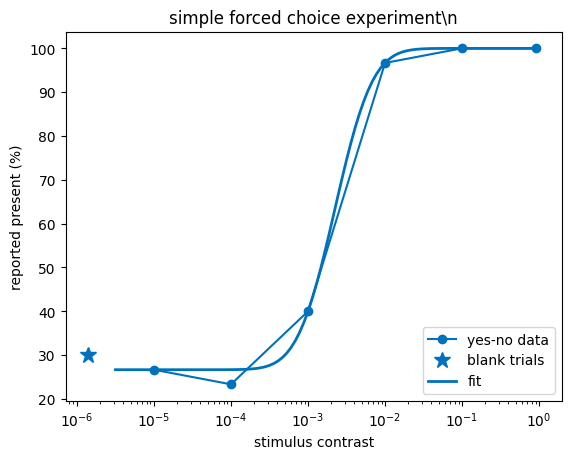

In [12]:
# plot signal detection results
fig, ax = plt.subplots()
ax.plot(
    positive_detection_results["contrast"], positive_detection_results["mean_response"] * 100,
    'o-', color=rgb[0], markerfacecolor=rgb[0]
)
if not blank_detection_results.empty:
    ax.plot(
        x_val_for_detection_blanks, blank_detection_results["mean_response"].iloc[0] * 100,
        marker='*', markersize=12, linestyle='None', color=rgb[0], markerfacecolor=rgb[0]
    )
ax.set_xscale('log')
ax.set_title("simple forced choice experiment\\n")
ax.set_xlabel('stimulus contrast')
ax.set_ylabel('reported present (%)')

# add fitted curve
ax.plot(psy_x, psy_y_detection * 100, '-', color=rgb[0], linewidth=2)
ax.legend(["yes-no data", "blank trials", "fit"], loc='lower right')
plt.show()

**What do you think?** Did the optimization procedure do a good job fitting your data? Are some adjustments needed?

## Part B. Two-Alternative Forced Choice (2AFC)

### Step 1. Data collection

To collect data, open the PsychoPy ".psyexp" file in the folder titled "forced-choice", and run that experiment. The instructions will appear on the screen before the trials begin. The experiment includes 210 trials.

### Step 2. Load your data

Before running this section of code, find the name of the ".csv" file containing your experiment data, and enter it below.

In [25]:
# change the filename to the one you generated during data collection
choice_file = Path.cwd() / "forced-choice" / "data"

choice_subject = "demo" # Change this to the subject number or name you want to analyze for this week's experiment

choice_subject_pattern = re.compile(rf"^{choice_subject}_")

matches = [f for f in choice_file.iterdir() if f.is_file() and f.suffix == '.csv' and choice_subject_pattern.match(f.name)]

# load the data table
choice_data = pd.read_csv(matches[0])

# remove the rows/columns associated with the instructions in psychopy
choice_data = choice_data.iloc[1:].reset_index(drop=True)
remove = ['notes','begin_experiment_started','begin_experiment_stopped']
choice_data = choice_data.drop(columns=remove, errors='ignore')

### Step 3. Analyze your data

For this experiment, the stimulus was a sinusoidal grating with a Gaussian mask. As a reminder, the grayscale luminance range in PsychoPy is -1 to 1, where -1 is black, 1 is white, and 0 is middle gray. The background luminance was set to 0. Thus, if the stimulus contrast were 0, the grating would be middle gray (the same luminance as the background), and if the stimulus contrast were 1, the grating's luminance would range from black to white.

PsychoPy saved the stimulus contrast, stimulus location (1 = right; -1 = left), and the participant's response per trial. The responses were stored as 'left' or 'right'.

In [ ]:
n_trials = len(choice_data)
trials = np.arange(1, n_trials + 1)

# extract the stimulus's contrast level and location
stim_contrast = choice_data["contrast"].to_numpy(dtype=float)
stim_location = choice_data["location"].to_numpy(dtype=float)

# extract the response data
resp_key = choice_data["response.keys"].astype(str)

# convert the response key to 1 for right and -1 for left
# (to match stimulus location)
resp_location = np.where(resp_key.eq('right'), 1, -1)

#### Visualize the response per trial

Let's start by taking a look at the data for each trial. Plot the contrast level (dots) and an indicator of the participant's response (circles), with the color of each differentiating between left (blue) and right (orange).

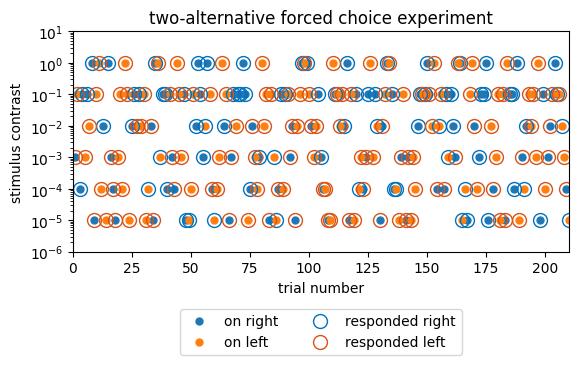

In [38]:
fig = plt.figure()
gs = fig.add_gridspec(5, 1, hspace=0.05)
ax = fig.add_subplot(gs[:3, 0])

# first, plot the stimulus contrast on a log scale
# (trials with zero contrast will not be included)
positive_stim = stim_contrast > 0
ax.plot(trials[(stim_location == 1) & positive_stim], stim_contrast[(stim_location == 1) & positive_stim],
        '.', markersize=10)  # stimuli on the right
ax.plot(trials[(stim_location == -1) & positive_stim], stim_contrast[(stim_location == -1) & positive_stim],
        '.', markersize=10)  # stimuli on the left
ax.set_yscale('log')
ax.set_title("two-alternative forced choice experiment")
ax.set_xlabel('trial number')
ax.set_xlim((0, n_trials))
ax.set_ylabel('stimulus contrast')
ax.set_ylim((10.0 ** -6, 10.0 ** 1))

# add circles indicating the participant's response
ax.plot(trials[(resp_location == 1) & positive_stim], stim_contrast[(resp_location == 1) & positive_stim],
        'o', markersize=10, color=rgb[0], markerfacecolor='none')  # responsed on the right
ax.plot(trials[(resp_location == -1) & positive_stim], stim_contrast[(resp_location == -1) & positive_stim],
        'o', markersize=10, color=rgb[1], markerfacecolor='none')  # responded on the left
ax.legend(['on right', 'on left', 'responded right', 'responded left'],
          loc='lower center', bbox_to_anchor=(0.5, -0.5), ncol=2)
plt.show()

#### Determine whether responses were correct or incorrect

For a response to be correct, the location of the stimulus and the location that the participant reported must match (i.e., both 'left' or both 'right').

In [39]:
# do stimulus and response locations match?
resp_correct = stim_location == resp_location

# display results
print(f"Overall percentage correct = {np.mean(resp_correct) * 100:.2f}%")

Overall percentage correct = 73.33%


#### Determine percentage correct per contrast level

For each contrast level, how often did you choose the correct side of the screen?

In [50]:
# average across responses per contrast level
analysis_table = pd.DataFrame({"response": resp_correct, "contrast": stim_contrast})
choice_results = (
    analysis_table
    .groupby('contrast', as_index=False)
    .agg(
        mean_response=('response', 'mean'),
        n_correct=('response', 'sum'),
        n_trials=('response', 'size')
    )
)
choice_results["n_correct"] = choice_results["n_correct"].astype(int)
choice_results["n_trials"] = choice_results["n_trials"].astype(int)

# display percentages
percent_correct = pd.DataFrame({
    "contrast": choice_results["contrast"],
    "correct responses (%)": choice_results["mean_response"] * 100
})
percent_correct = percent_correct.style.format(lambda x: f"{x:.6f}".rstrip('0').rstrip('.'))
display(percent_correct)

,contrast,correct responses (%)
0,0.00001,46.666667
1,0.0001,50
2,0.001,53.333333
3,0.01,63.333333
4,0.1,100
5,1,100


**Take a look at these percentages.** What is the maximum? What is the minimum?

**Think about the design of this experiment** (i.e., what the stimuli looked like, what the task was, what the potential responses were, etc.). What results would you get if you were performing at chance level?

**Looking again at your results,** when did you perform at, above, and below chance level? What does that say about what contrast levels you can and cannot see? Is there a clear boundary or gradual transition between the levels you definitely can and definitely cannot see?

#### Plot percentage correct as a function of contrast

Let's plot these percentages and check out the curve they form.

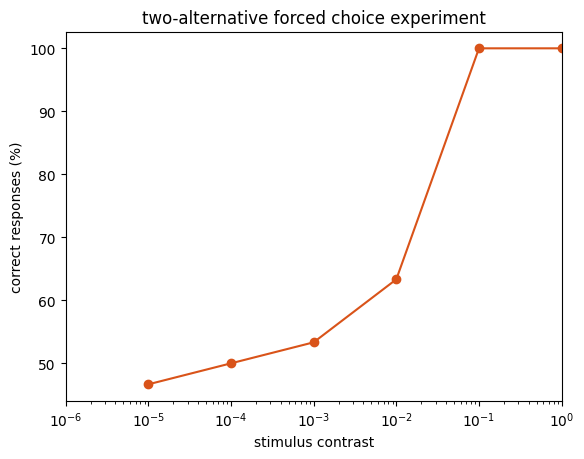

In [42]:
fig, ax = plt.subplots()

positive_choice_results = choice_results[choice_results["contrast"] > 0]

# plot with stimulus contrast on a log scale
# (trials with zero contrast will not be included)
ax.plot(
    positive_choice_results["contrast"], positive_choice_results["mean_response"] * 100,
    'o-', color=rgb[1], markerfacecolor=rgb[1]
)
ax.set_xscale('log')
ax.set_title("two-alternative forced choice experiment")
ax.set_xlabel('stimulus contrast')
ax.set_xlim(psy_x_lim)
ax.set_ylabel('correct responses (%)')
plt.show()

**What's your take?** Is this about what you expected? Does anything surprise you?

**Recall our four function parameters**: mu ($\mu$), sigma ($\sigma$), guess rate ($\gamma$), and lapse rate ($\lambda$). Can you guess what they might end up being? Give it a try before you go to the next step.

### Step 4. Fit a psychometric curve to your data

We've already covered what a psychometric curve is and done the necessary curve fitting setup, so we can get right to trying to fit data from our 2AFC task!

#### Fit your data

In [ ]:
# fit function to data using psignifit
if ps is None:
    raise ImportError("psignifit is required for fitting the 2AFC psychometric function. Install it with: pip install psignifit")

positive_choice_fit_results = choice_results[choice_results["contrast"] > 0].copy()

choice_psignifit_data = np.column_stack([
    np.log10(positive_choice_fit_results["contrast"].to_numpy(dtype=float)),
    positive_choice_fit_results["n_correct"].to_numpy(dtype=float),
    positive_choice_fit_results["n_trials"].to_numpy(dtype=float)
])

def fit_psignifit_2afc(data):
    try:
        return ps.psignifit(data, experiment_type="2AFC", sigmoid="norm")
    except TypeError:
        options = {
            "expType": "2AFC",
            "sigmoidName": "norm"
        }
        return ps.psignifit(data, options)

def psignifit_parameter_array(result):
    if hasattr(result, "parameter_estimate"):
        params = result.parameter_estimate
        try:
            mu, sigma = result.standard_parameter_estimate()
        except Exception:
            mu = params.get("threshold", np.nan)
            sigma = params.get("width", np.nan)
        return np.array([
            mu,
            sigma,
            params.get("gamma", 0.5),
            params.get("lambda", np.nan)
        ], dtype=float)

    if isinstance(result, dict):
        fit = np.asarray(result["Fit"], dtype=float)
        # psignifit 4 Python-style order is [threshold, width, lambda, gamma, eta]
        return np.array([
            fit[0],
            fit[1],
            fit[3] if fit.size > 3 else 0.5,
            fit[2] if fit.size > 2 else np.nan
        ], dtype=float)

    raise TypeError("Could not read fitted parameters from this psignifit result object.")

def psignifit_predict(result, x):
    x = np.asarray(x, dtype=float)

    if hasattr(result, "proportion_correct"):
        return np.asarray(result.proportion_correct(x), dtype=float)

    if isinstance(result, dict):
        return psyfxn(psignifit_parameter_array(result), x)

    raise TypeError("Could not evaluate predictions from this psignifit result object.")

choice_psignifit_result = fit_psignifit_2afc(choice_psignifit_data)
psyfit_choice = psignifit_parameter_array(choice_psignifit_result)

choice_pred_at_data = psignifit_predict(choice_psignifit_result, choice_psignifit_data[:, 0])
resnorm_choice = float(np.sum((choice_pred_at_data - positive_choice_fit_results["mean_response"].to_numpy(dtype=float)) ** 2))

# display results
print(
    f"        mu = {psyfit_choice[0]:.4f}\n"
    f"     sigma = {psyfit_choice[1]:.4f}\n"
    f"guess rate = {psyfit_choice[2]:.4f}\n"
    f"lapse rate = {psyfit_choice[3]:.4f}\n"
    f"\n   resnorm = {resnorm_choice:.4f}"
)


        mu = -1.8945
     sigma = 0.4698
guess rate = 0.5000
lapse rate = 0.0000

   resnorm = 0.0074


**What do you think?** Do these values look reasonable to you? Are they different from what you expected? Did you get a much different resnorm this time? (If so, what does that mean for how the psychometric curve will look compared to the data?)

#### Create a curve to plot

In [44]:
# use psychometric curve function to calculate y values
psy_y_choice = psignifit_predict(choice_psignifit_result, np.log10(psy_x))  # use same x values as above

#### Plot fitted psychometric curve

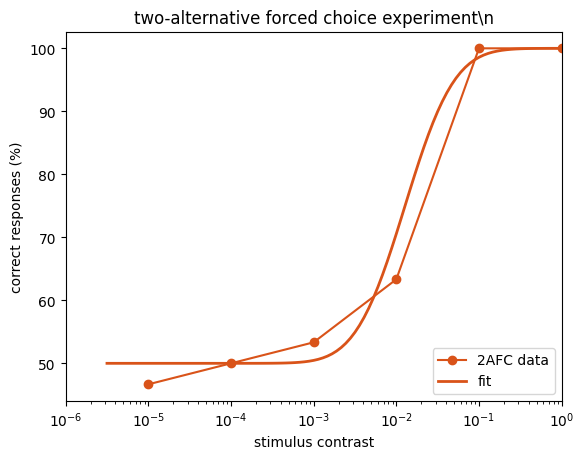

In [45]:
# plot forced choice results
fig, ax = plt.subplots()
ax.plot(
    positive_choice_results["contrast"], positive_choice_results["mean_response"] * 100,
    'o-', color=rgb[1], markerfacecolor=rgb[1]
)
ax.set_xscale('log')
ax.set_title("two-alternative forced choice experiment\\n")
ax.set_xlabel('stimulus contrast')
ax.set_xlim(psy_x_lim)
ax.set_ylabel('correct responses (%)')

# add fitted curve
ax.plot(psy_x, psy_y_choice * 100, '-', color=rgb[1], linewidth=2)
ax.legend(["2AFC data", "fit"], loc='lower right')
plt.show()

**What do you think?** Did the optimization procedure do a good job fitting this data? Are adjustments needed this time around?

## Part C. Compare Forced Choice Experiments

You've now collected, analyzed, and fit data from a **simple forced choice** experiment and a **two-alternative forced choice (2AFC)** experiment. What are the similarities and differences between these two types of experiments? Do they produce similar data, or are there differences worth noting?

### Step 1. Compare performance

To make comparing and contrasting easier, let's plot the data from both experiments in the same figure.

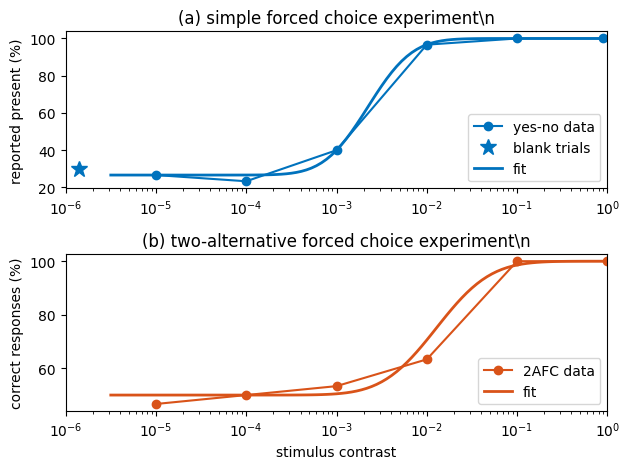

In [46]:
fig, (ax1, ax2) = plt.subplots(2, 1)

# plot signal detection results
ax1.plot(
    positive_detection_results["contrast"], positive_detection_results["mean_response"] * 100,
    'o-', color=rgb[0], markerfacecolor=rgb[0]
)
if not blank_detection_results.empty:
    ax1.plot(
        x_val_for_detection_blanks, blank_detection_results["mean_response"].iloc[0] * 100,
        marker='*', markersize=12, linestyle='None', color=rgb[0], markerfacecolor=rgb[0]
    )
ax1.plot(psy_x, psy_y_detection * 100, '-', color=rgb[0], linewidth=2)
ax1.set_xscale('log')
ax1.set_xlim(psy_x_lim)
ax1.set_title("(a) simple forced choice experiment\\n")
ax1.set_ylabel('reported present (%)')
ax1.legend(["yes-no data", "blank trials", "fit"], loc='lower right')

# plot forced choice results
ax2.plot(
    positive_choice_results["contrast"], positive_choice_results["mean_response"] * 100,
    'o-', color=rgb[1], markerfacecolor=rgb[1]
)
ax2.plot(psy_x, psy_y_choice * 100, '-', color=rgb[1], linewidth=2)
ax2.set_xscale('log')
ax2.set_xlim(psy_x_lim)
ax2.set_title("(b) two-alternative forced choice experiment\\n")
ax2.set_xlabel('stimulus contrast')
ax2.set_ylabel('correct responses (%)')
ax2.legend(["2AFC data", "fit"], loc='lower right')
plt.tight_layout()
plt.show()

**What do you notice?** What's similar? What's different? Can you explain why those things are similar or different?

### Step 2. Compare psychometric curves

Let's zoom in and take a look at the parameter values for these two psychometric functions. (And we'll throw in the resnorm for fun.)

In [49]:
# organize values in a table
fit_results = pd.DataFrame(
    {
        "yes-no": np.r_[psyfit_detection, resnorm_detection],
        "2afc": np.r_[psyfit_choice, resnorm_choice],
    },
    index=["mu", "sigma", "guess rate", "lapse rate", "resnorm"]
)
fit_results["diff"] = fit_results["yes-no"] - fit_results["2afc"]
display(fit_results)

,yes-no,2afc,diff
mu,-2.651011,-1.894509e+00,-0.756502
sigma,0.383742,4.698325e-01,-0.086091
guess rate,0.266668,5.000000e-01,-0.233332
lapse rate,0.000121,1.783721e-09,0.000121
resnorm,0.002233,7.356538e-03,-0.005123


**What do you think?** How similar or different are each of the values? (The differences are shown in the 3rd column to make comparing easier; positive values indicate yes-no > 2AFC.)

Which parameter is the most similar? Which is the most different? Does that surprise you?

Was one fit much better or worse than the other? Does that line up with what you expected based on the plots?

### Step 3. Compare the participant experience

As a final step, think back to collecting data for these two experiments. **Considering the participant's experience of a task is a crucial part of experiment development**, so reflect on your experience with these two types of forced choice tasks. Did you prefer one over the other? What do you think are the pros and cons of both from the participant's perspective? Does anything come to mind that changes your thoughts about how the data compare?